# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [3]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [4]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: UCI ML Repository fallback (id=292)
Dữ liệu đầy đủ: 440 dòng × 7 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

In [5]:
# Analysis workspace — thêm cell EDA của bạn bên dưới hoặc thay cell này.
# Gợi ý khởi đầu (không bắt buộc):
display(X_raw.describe().T)
# 1. Missing values
print("=== Missing values ===")
print(X_raw.isna().sum().sum())

# 2. Duplicate rows
print("\n=== Duplicates ===")
print("Số dòng trùng lặp:", X_raw.duplicated().sum())

# 3. Kiểu dữ liệu
print("\n=== Dtypes ===")
print(X_raw.dtypes)

# 4. Giá trị 0
print("\n=== Số lượng giá trị = 0 ===")
print((X_raw == 0).sum().sum())

# 5. Điểm cực trị / độ lệch (outlier signal)
print("\n=== So sánh Max vs Median (tỉ lệ càng cao = outlier càng mạnh) ===")
print((X_raw.max() / X_raw.median()).round(1))


,count,mean,std,min,25%,50%,75%,max
Fresh,440.00,"12,000.30","12,647.33",3.00,"3,127.75","8,504.00","16,933.75","112,151.00"
Milk,440.00,"5,796.27","7,380.38",55.00,"1,533.00","3,627.00","7,190.25","73,498.00"
Grocery,440.00,"7,951.28","9,503.16",3.00,"2,153.00","4,755.50","10,655.75","92,780.00"
Frozen,440.00,"3,071.93","4,854.67",25.00,742.25,"1,526.00","3,554.25","60,869.00"
Detergents_Paper,440.00,"2,881.49","4,767.85",3.00,256.75,816.50,"3,922.00","40,827.00"
Delicassen,440.00,"1,524.87","2,820.11",3.00,408.25,965.50,"1,820.25","47,943.00"


=== Missing values ===
0

=== Duplicates ===
Số dòng trùng lặp: 0

=== Dtypes ===
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

=== Số lượng giá trị = 0 ===
0

=== So sánh Max vs Median (tỉ lệ càng cao = outlier càng mạnh) ===
Fresh              13.20
Milk               20.30
Grocery            19.50
Frozen             39.90
Detergents_Paper   50.00
Delicassen         49.70
dtype: float64


Một dòng dữ liệu đại diện cho tiêu dùng của một khách hàng cho thực phẩm trong một năm

Không có dữ liệu nào bị thiếu, trùng lặp, bị sai, không có giá trị nào = 0 cả. Mọi cột đều có độ lệch phải mạnh (dựa vào max/median)

Channel/Region thì nên được dùng ở giai đoạn validation sau khi đã cluster labels. Nếu cho Channel/Region vào ban đầu thì các dữ liệu có sẵn sẽ được gắn nhãn, không còn là bài unsupervised nữa

Với chỉ dữ liệu chi tiêu, “hữu ích” có nghĩa là sẽ có thể phân biệt được các tệp khách hàng (ví dụ: Khách hàng chi tiêu vào các hàng tươi sống, hàng đông lạnh,...) chứ không phải nhìn vào Silhouette hay Davies-Bouldin (DB)

# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

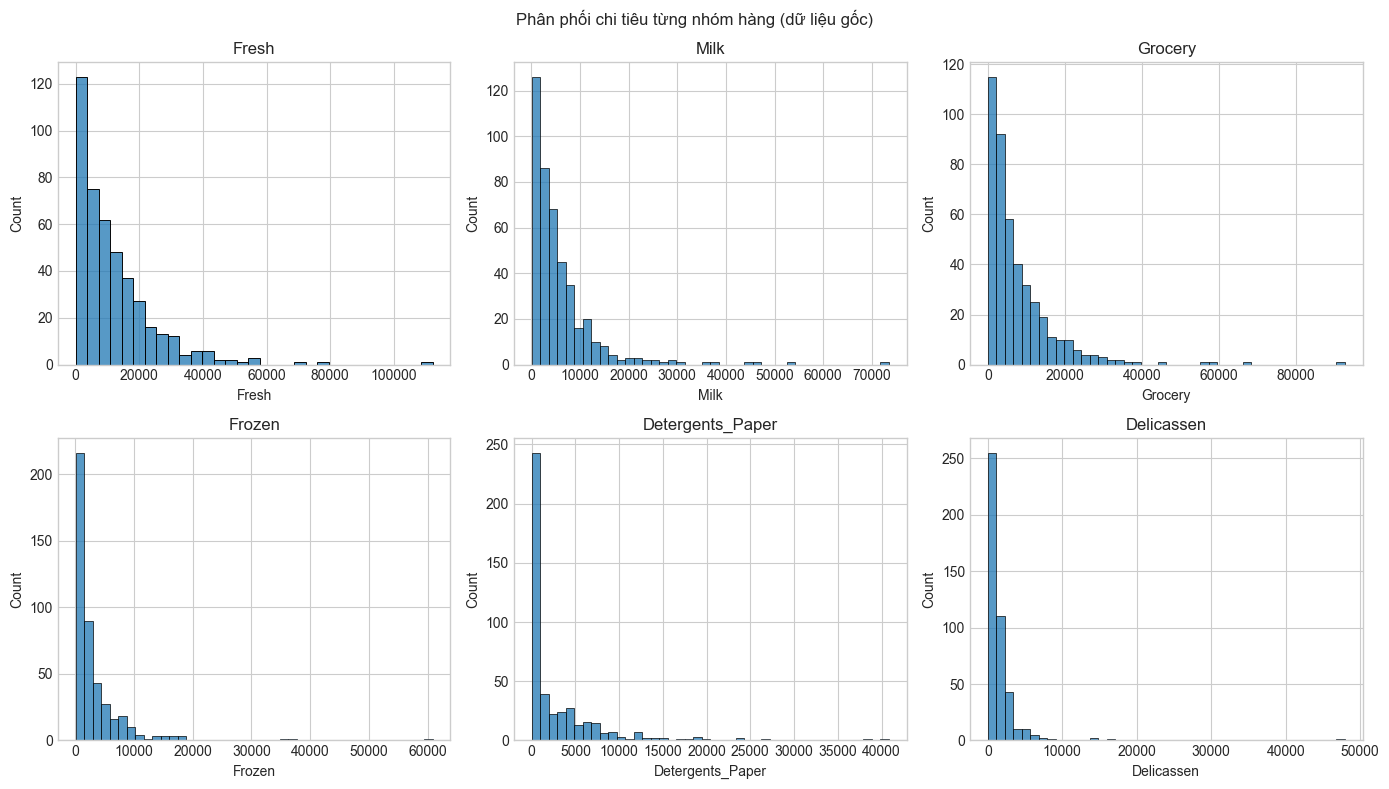

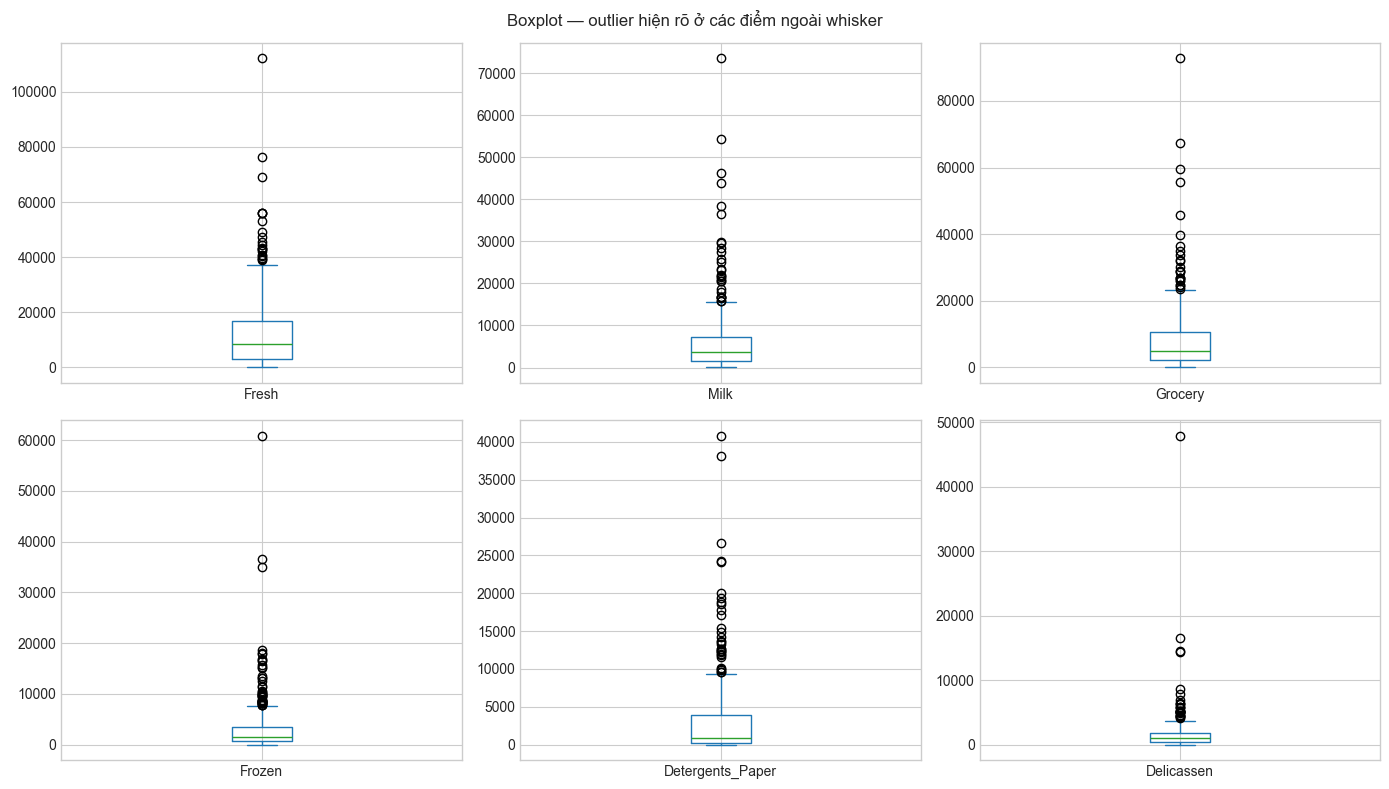

In [6]:
import seaborn as sb

# 1. Phân phối + độ lệch + outlier

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, SPENDING_FEATURES):
    sb.histplot(x=X_raw[col],ax=ax)
    ax.set_title(col)
plt.suptitle("Phân phối chi tiêu từng nhóm hàng (dữ liệu gốc)")
plt.tight_layout()
# Boxplot để thấy outlier rõ hơn
X_raw.plot(kind='box', subplots=True, layout=(2,3), figsize=(14,8), sharey=False)
plt.suptitle("Boxplot — outlier hiện rõ ở các điểm ngoài whisker")
plt.tight_layout()
plt.show()

# Trả lời câu 1 và 2
1/ Phân phối lệch phải mạnh + nhiều outlier khiến Euclidean distance (dùng bình phương chênh lệch) bị vài khách hàng cực lớn chi phối => 2 khách hàng bình thường có thể bị coi là cách xa nhau chỉ vì 1 trong 2 có giá trị đột biến ở 1 cột.

2/ Fresh và Grocery có range lớn hơn hẳn Delicassen/Frozen — nếu không scale, 2 cột này sẽ áp đảo khoảng cách Euclidean, khiến các cột chi tiêu nhỏ gần như không có tiếng nói trong việc phân cụm.

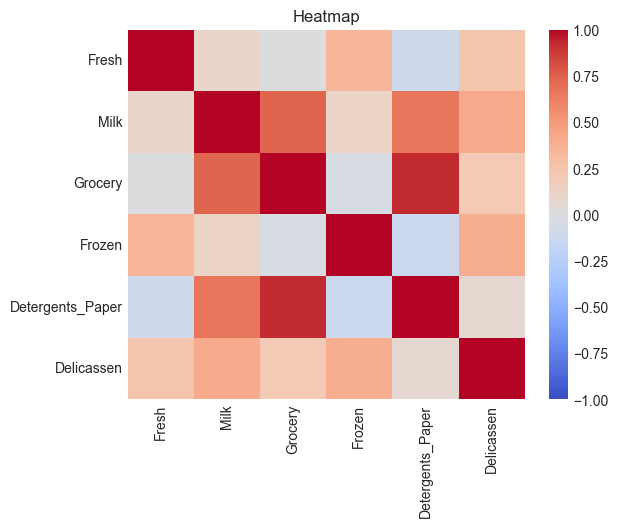

In [7]:
ax = sb.heatmap(X_raw.corr(), cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title("Heatmap")

plt.show()

# Trả lời câu 3 4
3/ Grocery, Milk, Detergents_Paper tương quan dương mạnh (khoảng 0.7-0.9), gợi ý đây là nhóm 'hàng siêu thị/bán lẻ' đi cùng nhau. Fresh tương quan yếu với nhóm này, có thể tách biệt thành 1 trục hành vi riêng (mua hàng tươi). Điều này quan trọng khi đặt tên cụm sau này — cụm nào cao ở Grocery thường sẽ cao luôn ở Milk và Detergents.

4/ Do độ lệch mạnh nên cần phải biến đổi để có thể nén long tail. Hơn nữa do có vài cột range lớn hơn các cột khác nhiều nên cần phải scale lại bằng z-score. 

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

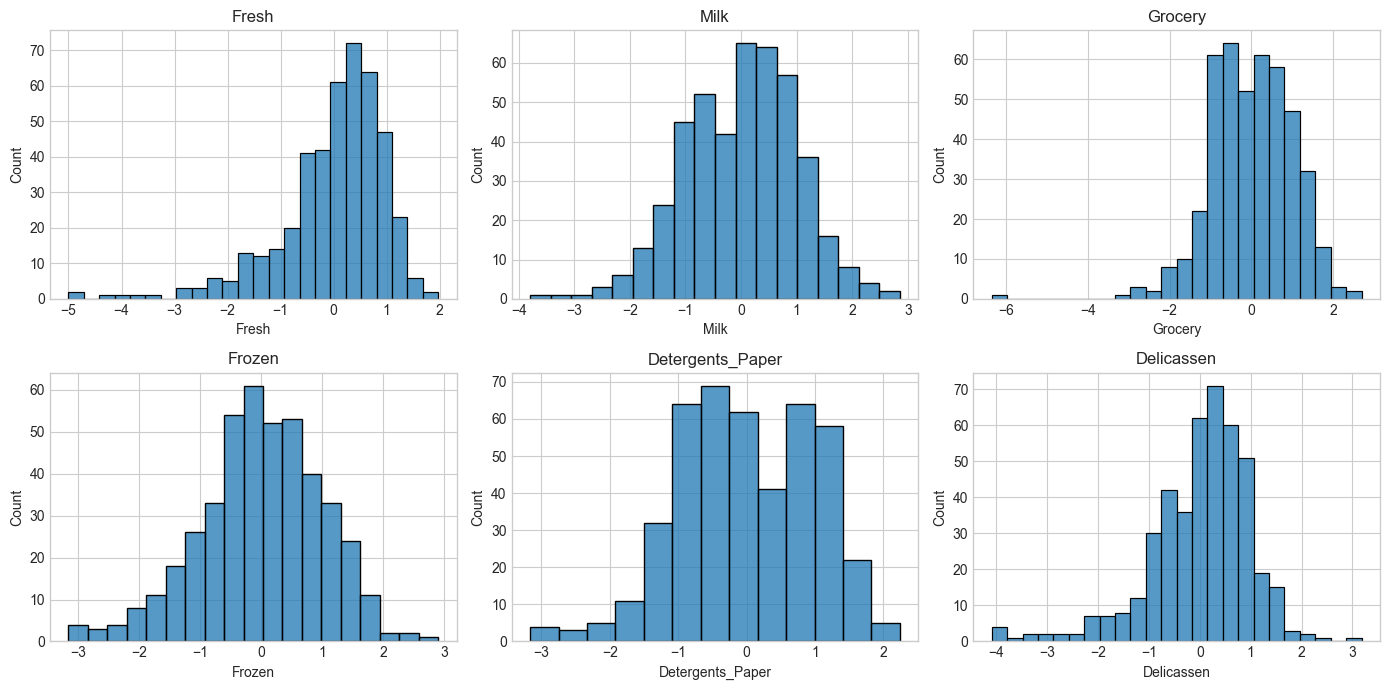

In [8]:
X_log = np.log1p(X_raw) #Nén outlier bằng log1p


X_model = pd.DataFrame(
    StandardScaler().fit_transform(X_log),
    columns=X_raw.columns
) 
#Scale lại các giá trị của X_log,đảm bảo Euclidean distance không bị chi phối bởi cột có range lớn hơn. Đây cũng là matrix để fit model

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, col in zip(axes.flat, SPENDING_FEATURES):
    sb.histplot(X_model[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Trade-off: khoảng cách trong không gian log1p không còn phản ánh chênh lệch chi tiêu tuyệt đối (bằng tiền) nữa, vì giá trị càng lớn thì càng bị nén chặt => số tiền chi ra càng lớn thì được xếp vào cùng nhóm. Chính vị vậy nếu mục tiêu là tìm ra tệp khách hàng có chi tiêu lớn thì kết quả clustering không còn phản ánh đúng nữa.


# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

# K means

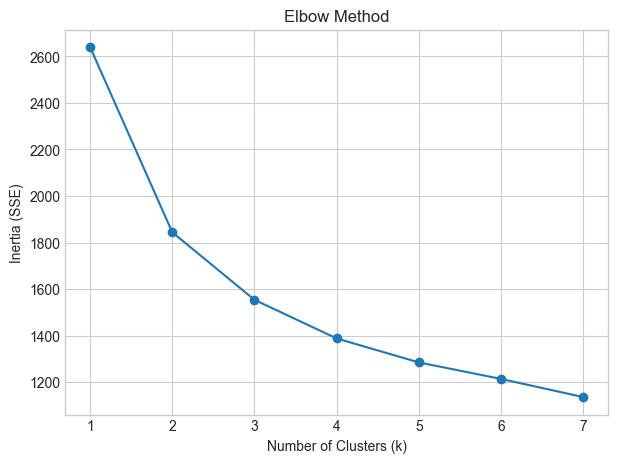

In [9]:

inertias = []

for k in range(1, 8):
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init='auto'
    )
    km.fit(X_model)
    inertias.append(km.inertia_)
plt.figure(figsize=(7,5))
plt.plot(range(1, 8), inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

Giá trị k=2 khả thi, chọn k = 2

# Hierarchical clustering

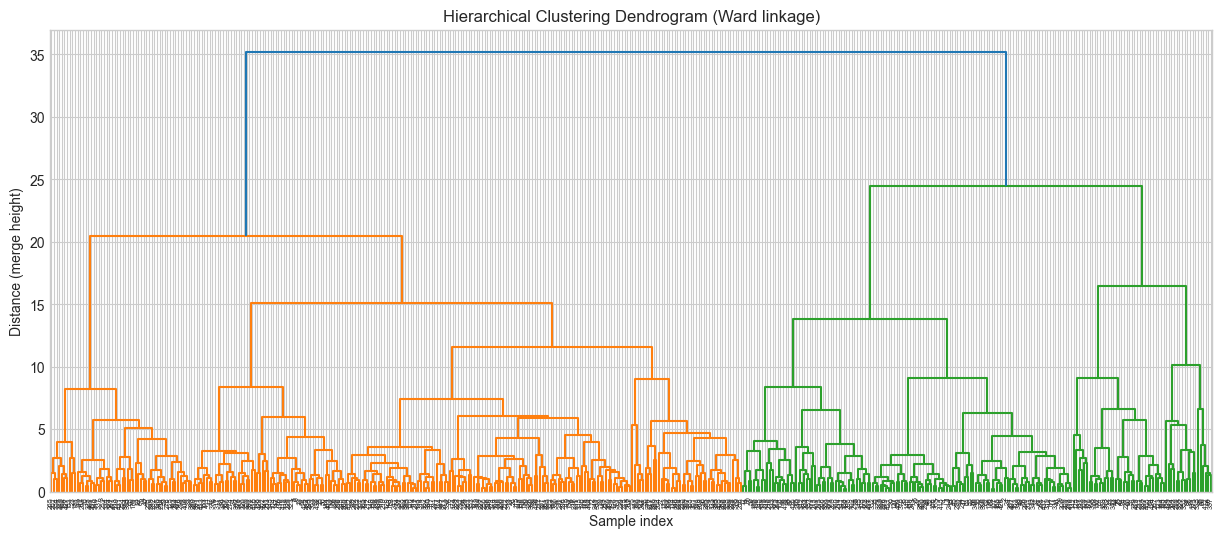

Silhouette theo từng n_clusters
n_clusters=2 | silhouette=0.258 | cluster sizes=[262, 178]
n_clusters=3 | silhouette=0.255 | cluster sizes=[262, 125, 53]
n_clusters=4 | silhouette=0.202 | cluster sizes=[208, 125, 54, 53]
n_clusters=5 | silhouette=0.203 | cluster sizes=[208, 125, 54, 35, 18]
n_clusters=6 | silhouette=0.171 | cluster sizes=[150, 125, 58, 54, 35, 18]
n_clusters=7 | silhouette=0.163 | cluster sizes=[150, 76, 58, 54, 49, 35, 18]


In [23]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score

Z = linkage(X_model, method='ward')

plt.figure(figsize=(15, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage)")
plt.xlabel("Sample index")
plt.ylabel("Distance (merge height)")
plt.show()

print("Silhouette theo từng n_clusters")
for n in [2,3,4,5,6,7]:
    hc = AgglomerativeClustering(n_clusters=n, metric='euclidean', linkage='ward')
    labels = hc.fit_predict(X_model)
    score = silhouette_score(X_model, labels)
    sizes = pd.Series(labels).value_counts().tolist()
    print(f"n_clusters={n} | silhouette={score:.3f} | cluster sizes={sizes}")

Chọn n_cluster = 2

# DBSCAN

In [64]:
results = []
for eps in [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]:
    for min_samples in [5, 10, 15]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_model)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_rate = (labels == -1).sum() / len(labels)
        
        # chỉ tính silhouette nếu có >1 cụm và không phải toàn noise
        if n_clusters > 1:
            mask = labels != -1
            if mask.sum() > 1 and len(set(labels[mask])) > 1:
                sil = silhouette_score(X_model[mask], labels[mask])
            else:
                sil = None
        else:
            sil = None
            continue
        
        results.append({
            'eps': eps, 'min_samples': min_samples,
            'n_clusters': n_clusters, 'noise_rate': round(noise_rate, 3),
            'silhouette': round(sil, 3) if sil else None
        })

results_df = pd.DataFrame(results)
display(results_df)

,eps,min_samples,n_clusters,noise_rate,silhouette
0,0.80,5,3,0.52,0.29
1,0.80,10,2,0.76,0.54
2,0.80,15,2,0.89,0.59


DBSCAN không phù hợp vì noise rate quá cao (lớn hơn 0.5) => Không dùng

In [65]:
Km = KMeans(n_clusters=2, n_init='auto', random_state=RANDOM_STATE)
labels_Km = Km.fit_predict(X_model)

hc = AgglomerativeClustering(n_clusters=2, metric='euclidean',linkage='ward')
labels_hc = hc.fit_predict(X_model)

print("K-Means cluster sizes:", pd.Series(labels_Km).value_counts().sort_index().tolist())
print("Hierarchical cluster sizes:", pd.Series(labels_hc).value_counts().sort_index().tolist())

K-Means cluster sizes: [187, 253]
Hierarchical cluster sizes: [178, 262]


# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

In [75]:
print("=== Chất lượng nội bộ (K=2) ===")
print(f"K-Means      | Silhouette: {silhouette_score(X_model, labels_Km):.3f} | Davies-Bouldin: {davies_bouldin_score(X_model, labels_Km):.3f}")
print(f"Hierarchical | Silhouette: {silhouette_score(X_model, labels_hc):.3f} | Davies-Bouldin: {davies_bouldin_score(X_model, labels_hc):.3f}")

print("\nCluster sizes:")
print("K-Means:     ", pd.Series(labels_Km).value_counts().sort_index().tolist())
print("Hierarchical:", pd.Series(labels_hc).value_counts().sort_index().tolist())


=== Chất lượng nội bộ (K=2) ===
K-Means      | Silhouette: 0.290 | Davies-Bouldin: 1.350
Hierarchical | Silhouette: 0.258 | Davies-Bouldin: 1.600

Cluster sizes:
K-Means:      [187, 253]
Hierarchical: [178, 262]


Ở đây ta thấy hai thuật toán đều chia được các cụm khá đồng đều, nhưng K-Means cho ra kết quả Silhouette lớn hơn và DB cũng nhỏ hơn, vì vậy K-means có thể là thuật toán tối ưu

In [ ]:
from sklearn.metrics import adjusted_rand_score

seeds = [3, 36, 363, 3636, 36363]
labels_by_seed = {}

for seed in seeds:
    km = KMeans(n_clusters=2, n_init='auto', random_state=seed)
    labels_by_seed[seed] = km.fit_predict(X_model)

print("=== So sánh nhãn giữa các seed khác nhau (ARI) ===")
base = labels_by_seed[36]
for seed in seeds:
    ari = adjusted_rand_score(base, labels_by_seed[seed])
    print(f"seed={seed} vs seed=36 | ARI = {ari:.3f}")

=== So sánh nhãn giữa các seed khác nhau (ARI) ===
seed=3 vs seed=42 | ARI = 1.000
seed=36 vs seed=42 | ARI = 1.000
seed=363 vs seed=42 | ARI = 1.000
seed=3636 vs seed=42 | ARI = 0.991
seed=36363 vs seed=42 | ARI = 0.991


``=> Vậy sẽ chọn thuật toán K means
``

# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


Variance explained: 71.3%


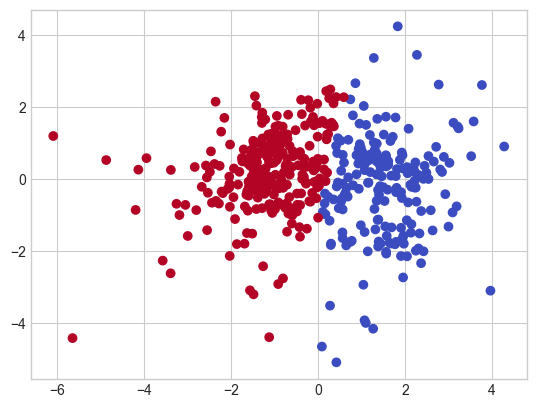

In [116]:
# Analysis workspace — visual cho model cuối.
# Có thể dùng PCA, nhưng không cần giới hạn ở PCA:
coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)
plt.scatter(x=coords[:, 0],y= coords[:, 1], c=labels_Km, cmap='coolwarm')

print(f"Variance explained: {pca.explained_variance_ratio_.sum():.1%}")

Model K-Means đã được fit trên đầy đủ 6 chiều gốc (X_model), PCA chỉ dùng để chiếu xuống 2D nhằm mục đích quan sát trực quan, không ảnh hưởng đến kết quả cluster.

PC1+PC2 chỉ giữ lại 71.3% variance của dữ liệu gốc, nghĩa là biểu đồ này không thể hiện đầy đủ cấu trúc 6 chiều, một phần thông tin đã bị mất khi chiếu xuống.

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

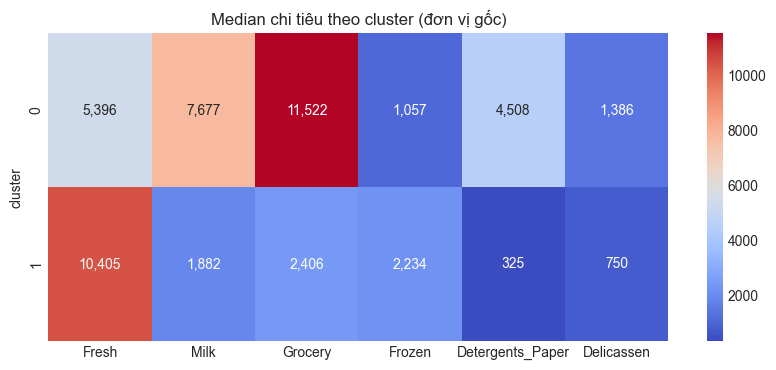

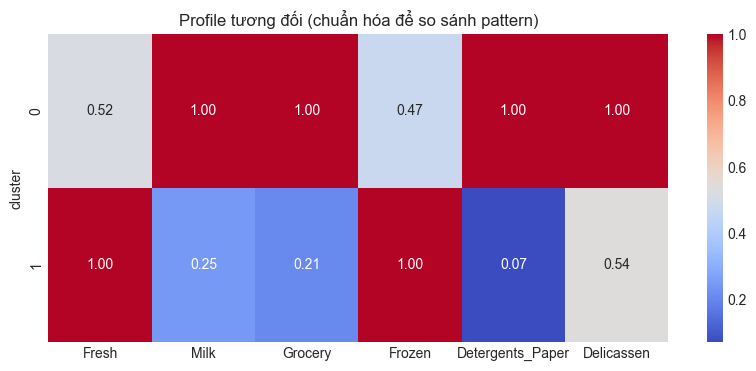

In [115]:
# Analysis workspace — profile trên X_raw và viết action hypothesis của bạn tại đây.
# Mẹo kỹ thuật (không bắt buộc):
# profile = X_raw.assign(cluster=labels_final).groupby('cluster').median()
# Dùng median (ít nhạy outlier hơn mean) — hợp lý vì data lệch phải mạnh
profile = X_raw.assign(cluster=labels_Km).groupby('cluster').median()
profile['n_customers'] = X_raw.assign(cluster=labels_Km).groupby('cluster').size()

# Heatmap để dễ nhìn pattern
plt.figure(figsize=(10, 4))
sb.heatmap(profile[SPENDING_FEATURES], annot=True, fmt=',.0f', cmap='coolwarm')
plt.title("Median chi tiêu theo cluster (đơn vị gốc)")
plt.show()

# Profile tương đối (chuẩn hóa mỗi cột về 0-1) — dễ so sánh tỷ trọng giữa các cụm
profile_relative = profile[SPENDING_FEATURES].div(profile[SPENDING_FEATURES].max())
plt.figure(figsize=(10, 4))
sb.heatmap(profile_relative, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Profile tương đối (chuẩn hóa để so sánh pattern)")
plt.show()

## Đặt tên cụm

| Cluster | n | Fresh | Milk | Grocery | Frozen | Detergents | Deli | Tên gợi ý |
|---|---|---|---|---|---|---|---|---|
| 0 | 187 | thấp | cao | cao | thấp | cao | cao | Grocery-focused |
| 1 | 253 | cao | thấp | thấp| cao | thấp | thấp | Fresh-focused |

**Evidence cho tên gọi**: Cluster 0 có Fresh/Frozen cao hơn hẳn nhưng Grocery/Detergents 
thấp → đặt tên "Fresh-focused". Cluster 1 ngược lại, cao ở Grocery/Milk/Detergents 
(khớp với correlation mạnh đã thấy ở TODO B) nhưng thấp Fresh → đặt tên "Grocery-focused".

## Action hypothesis

**Với Cluster "Fresh-focused"**: Giả thuyết là nhóm này gồm khách hàng loại 
Horeca (nhà hàng/khách sạn) cần giao hàng tươi thường xuyên. 
→ Đề xuất thử nghiệm: ưu tiên lịch giao hàng nhanh/lạnh cho nhóm này, 
đo hiệu quả qua tỷ lệ giữ chân khách hàng (retention) sau 3 tháng.

**Với Cluster "Grocery-focused"**: Giả thuyết là nhóm bán lẻ, mua hàng bổ 
sung định kỳ. 
→ Đề xuất thử nghiệm: chương trình đặt hàng tự động định kỳ (replenishment), 
đo hiệu quả qua tần suất đặt hàng tăng lên bao nhiêu %.

## Dữ liệu còn thiếu trước khi biến hypothesis thành quyết định

- **Lợi nhuận (margin)**: chỉ có doanh thu/chi tiêu, không biết margin thật của từng 
  nhóm hàng — 1 cụm chi nhiều Fresh có thể mang lại margin thấp hơn cụm chi Grocery 
  nếu margin Fresh thấp hơn.
- **Tần suất đặt hàng**: dữ liệu là tổng chi tiêu CẢ NĂM, không biết khách đặt 
  1 lần lớn hay nhiều lần nhỏ — ảnh hưởng trực tiếp tới đề xuất "lịch giao hàng".
- **Channel/Region thật** (nếu dataset gốc có): cần crosstab với cluster để confirm 
  giả thuyết "Fresh-focused = Horeca" có đúng thật không, hay chỉ là suy đoán.
- **Phản hồi khách hàng lịch sử**: chưa có dữ liệu về việc khách có phản hồi tốt 
  với thay đổi logistics tương tự trong quá khứ không.

# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.

## Checklist trước khi nộp

- [ ] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [ ] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [ ] Có ≥2 thuật toán và quyết định model có evidence.
- [ ] Có kiểm tra stability/robustness và diễn giải kết quả.
- [ ] Không đọc PCA 2D như bằng chứng duy nhất.
- [ ] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [ ] Có giới hạn và kết luận business rõ ràng.


## Executive Summary

**1. Có nên dùng ngay, thử nghiệm giới hạn, hay chưa nên dùng?**

Nên **thử nghiệm giới hạn** (pilot), chưa triển khai toàn bộ ngay. Cấu trúc 2 cụm 
khách hàng là có thật và ổn định (được xác nhận độc lập bởi 2 thuật toán khác nhau), 
nhưng mức độ tách biệt ở dạng vừa phải (silhouette ~0.26-0.29, không phải rất cao), 
nên nên thí điểm trên 1 nhóm nhỏ trước khi áp dụng toàn bộ.

**2. Quyết định model/preprocessing cuối và evidence ngắn gọn**

Chọn **K-Means, K=2**, fit trên dữ liệu đã qua log1p + StandardScaler. Preprocessing 
này cần thiết vì dữ liệu chi tiêu lệch phải rất mạnh (max/median lên tới 50 lần ở 
Detergents_Paper) và các cột có scale chênh lệch lớn. K=2 được chọn vì Elbow method 
(K-Means) và Silhouette (Hierarchical/Ward) độc lập đồng thuận cùng con số này, dù 
2 thuật toán có giả định hình học khác nhau — đây là bằng chứng đáng tin cậy. DBSCAN 
bị loại vì không tìm được cấu hình tham số cân bằng (mọi thử nghiệm đều rơi vào 
"gần hết là noise" hoặc "gộp hết thành 1 cụm").

**3. Hai insight profile quan trọng nhất**

[CẦN ĐIỀN SỐ THẬT từ bảng profile — ví dụ:]
- Cụm 1 (n=187 khách hàng) chi tiêu vượt trội ở Fresh/Frozen, thấp ở Grocery/
  Detergents — gợi ý nhóm khách hàng mua hàng tươi sống/dễ hỏng.
- Cụm 0 (n=253 khách hàng) ngược lại, mạnh ở Grocery/Milk/Detergents — gợi ý 
  nhóm mua hàng siêu thị/bổ sung định kỳ.

**4. Action thử trước và cách đánh giá**

Thử nghiệm: điều chỉnh lịch giao hàng — ưu tiên giao nhanh/tần suất cao hơn cho 
cụm thiên Fresh, giữ lịch cố định định kỳ cho cụm thiên Grocery. Đánh giá bằng 
A/B test trên 1 khu vực nhỏ trong 4-8 tuần, so sánh tỷ lệ đặt hàng lại (reorder 
rate) và phản hồi khách hàng giữa nhóm thí điểm và nhóm đối chứng.

**5. Giới hạn quan trọng nhất**

Dữ liệu chỉ có 6 cột chi tiêu hằng năm, không có lợi nhuận, tần suất đặt hàng, 
hay dữ liệu Channel/Region để đối chiếu. Cluster label là giả thuyết hành vi, 
chưa được kiểm chứng bằng dữ liệu vận hành thật — cần thu thập thêm trước khi 
biến thành quyết định chính thức.